# GeoBrain Acoustic Forward Modeling

Wave Propagation with Marmousi2 Model (2D).

Features:
- PML absorbing boundary
- Free surface condition
- Gradient checkpointing for memory efficiency
- Uses geobrain.io for SEGY loading
- Uses geobrain.vis for visualization

---

**Acoustic wave-equation modelling** uses finite differences to simulate
seismic wave propagation through the Earth.  This notebook runs a 2-D
acoustic simulation on the Marmousi2 benchmark velocity model.

Features: PML absorbing boundaries, free-surface condition, gradient
checkpointing for memory-efficient backpropagation.

In [1]:
import sys
sys.path.insert(0, '../..')

import os
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
from scipy import interpolate

matplotlib.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.titleweight': 'semibold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.framealpha': 0.9,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'image.cmap': 'viridis',
})

FIGS_DIR = os.path.join('..', 'figs')
os.makedirs(FIGS_DIR, exist_ok=True)

device = "cuda:0" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
print(f"Using device: {device}")

Using device: cpu


## Marmousi2 Loader

The [Marmousi2 model](https://wiki.seg.org/wiki/AGL_Elastic_Marmousi) is a
widely used geophysics benchmark at 1.25 m native resolution.  The loader
reads SEG-Y files and auto-detects units (km/s → m/s).
`resample_marmousi2()` interpolates the model onto the target grid.

In [2]:
def load_marmousi2_segy(segy_path: str):
    """
    Load Marmousi2 velocity model from SEGY file.

    Args:
        segy_path: Path to the SEGY file

    Returns:
        vp: Velocity model (nz, nx) in m/s
        dx_orig, dz_orig: Original grid spacing (m)
    """
    if not os.path.exists(segy_path):
        raise FileNotFoundError(f"SEGY file not found: {segy_path}")

    from geobrain.io import read_segy_volume
    vp_full, info = read_segy_volume(segy_path)

    dx_orig = 1.25  # Marmousi2 standard spacing
    dz_orig = 1.25

    # Convert km/s to m/s if needed
    if vp_full.max() < 10:
        print("Converting velocity from km/s to m/s...")
        vp_full = vp_full * 1000.0

    print(f"Loaded Marmousi2: {vp_full.shape[1]} x {vp_full.shape[0]} @ {dx_orig}m")
    print(f"Vp range: {vp_full.min():.0f} - {vp_full.max():.0f} m/s")

    return vp_full, dx_orig, dz_orig


def resample_marmousi2(vp_full, dx_orig, dz_orig, target_nx, target_nz,
                        x_start, dx_target, dz_target):
    """Resample Marmousi2 model to target grid."""
    nz_orig, nx_orig = vp_full.shape

    # Original coordinates
    x_orig = np.arange(nx_orig) * dx_orig
    z_orig = np.arange(nz_orig) * dz_orig

    # Target coordinates
    x_end = x_start + target_nx * dx_target
    z_end = target_nz * dz_target

    x_target = np.linspace(x_start, x_end - dx_target, target_nx)
    z_target = np.linspace(0, z_end - dz_target, target_nz)

    # Clip to valid range
    x_target = np.clip(x_target, x_orig.min(), x_orig.max() - dx_target)
    z_target = np.clip(z_target, z_orig.min(), z_orig.max() - dz_target)

    # Interpolate
    interp_func = interpolate.RegularGridInterpolator(
        (z_orig, x_orig), vp_full,
        method='linear', bounds_error=False, fill_value=None
    )

    Z_target, X_target = np.meshgrid(z_target, x_target, indexing='ij')
    points = np.stack([Z_target.ravel(), X_target.ravel()], axis=-1)
    vp_resampled = interp_func(points).reshape(target_nz, target_nx)

    print(f"Resampled to: {target_nx} x {target_nz} @ {dx_target}m")
    print(f"Vp range: {vp_resampled.min():.0f} - {vp_resampled.max():.0f} m/s")

    return vp_resampled

## Configuration

| Parameter | Value | Description |
|-----------|-------|-------------|
| Grid | 200 × 88 @ 40 m | Spatial grid |
| Time | 3000 steps × 3 ms = 9 s | Temporal extent |
| Wavelet | 5 Hz Ricker | Low frequency for the large-scale model |
| Offset | starts at x = 5 km | Subset of the full Marmousi2 model |

In [3]:
SEGY_FILE = "../data/marmousi/vp_marmousi-ii.segy"
PROJECT_PATH = "./data"

# Grid parameters
NX = 200
NZ = 88
DX = 40.0
DZ = 40.0

# Time parameters
NT = 3000
DT = 0.003
F0 = 5.0  # Wavelet frequency (Hz)

# Marmousi2 extraction start position
X_START = 5000  # Start at 5km

print(f"Grid: {NX} x {NZ} @ {DX}m")
print(f"Time: {NT} samples @ {DT*1000:.1f}ms = {NT*DT:.2f}s")
print(f"Wavelet frequency: {F0} Hz")

Grid: 200 x 88 @ 40.0m
Time: 3000 samples @ 3.0ms = 9.00s
Wavelet frequency: 5.0 Hz


## Load Velocity Model

Load and resample the Marmousi2 P-wave velocity.  Density is estimated from
velocity using the **Gardner relation**: $\rho = 310\,V_p^{0.25}$.


--- Loading Marmousi2 Velocity Model ---
Converting velocity from km/s to m/s...
Loaded Marmousi2: 13601 x 2801 @ 1.25m
Vp range: 1028 - 4700 m/s
Resampled to: 200 x 88 @ 40.0m
Vp range: 1500 - 4700 m/s
Density range: 1929 - 2567 kg/m3

--- Visualize Velocity and Density ---


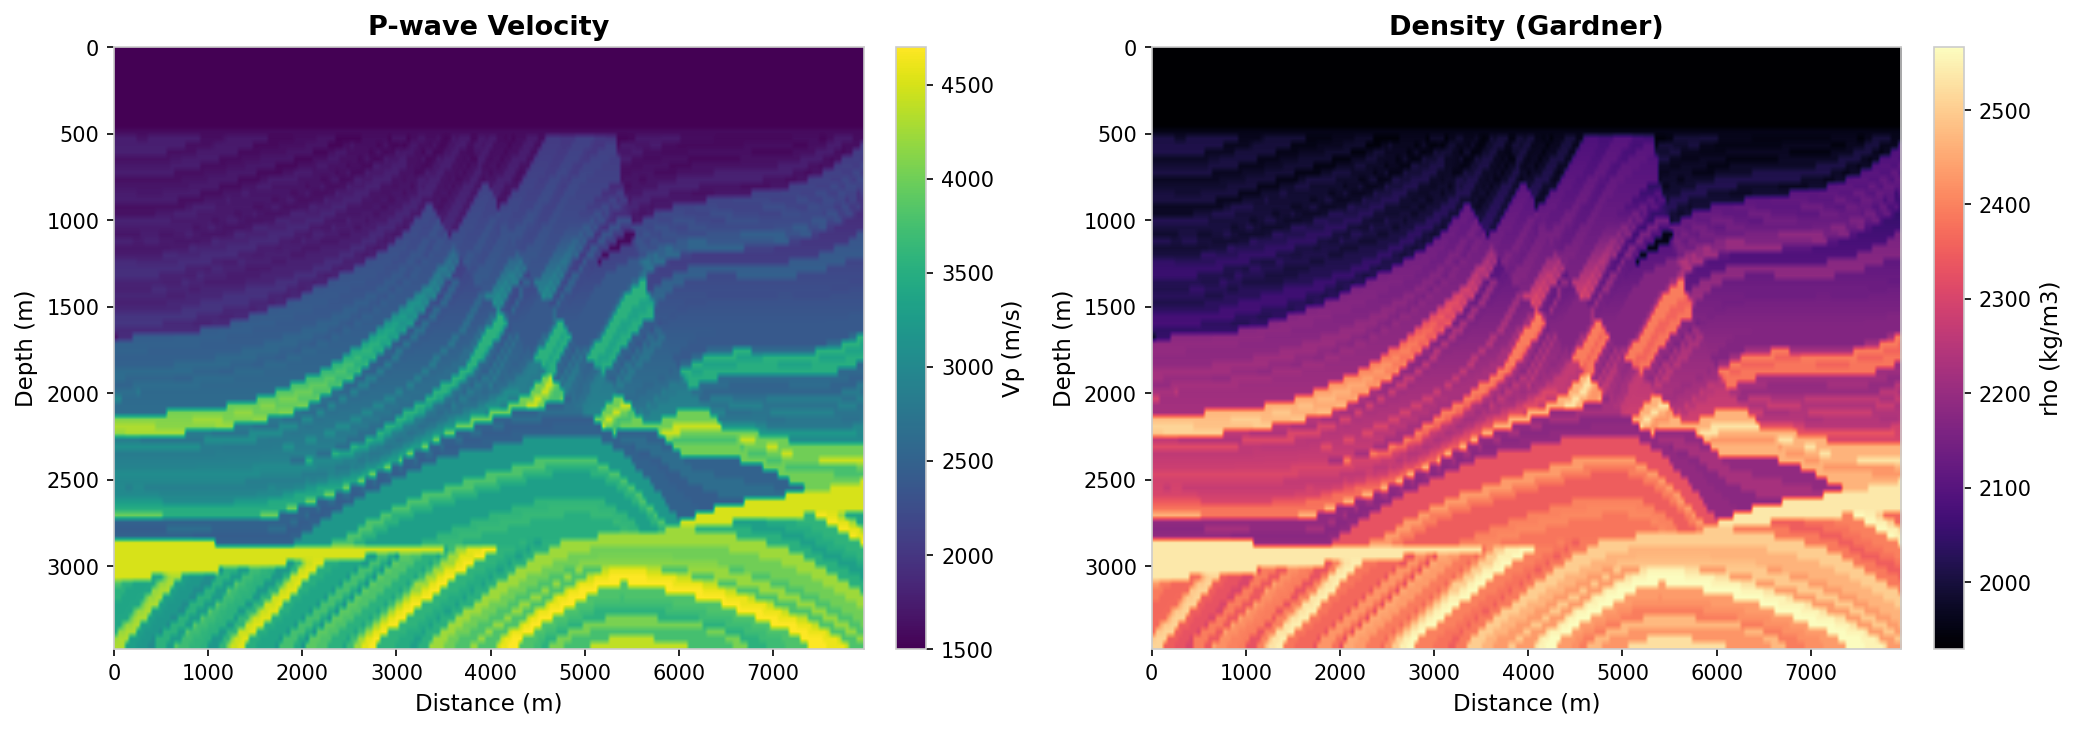

In [4]:
print("\n--- Loading Marmousi2 Velocity Model ---")

vp_full, dx_orig, dz_orig = load_marmousi2_segy(SEGY_FILE)

vp = resample_marmousi2(
    vp_full, dx_orig, dz_orig,
    target_nx=NX,
    target_nz=NZ,
    x_start=X_START,
    dx_target=DX,
    dz_target=DZ,
)

# Density from Gardner's relation
rho = np.power(vp, 0.25) * 310

print(f"Density range: {rho.min():.0f} - {rho.max():.0f} kg/m3")

# Visualize model
print("\n--- Visualize Velocity and Density ---")

from geobrain.vis import plot_field, plot_gather, plot_section

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_field(vp, dx=DX, dz=DZ, ax=axes[0], cmap='viridis', label='Vp (m/s)')
axes[0].set_title('P-wave Velocity')
plot_field(rho, dx=DX, dz=DZ, ax=axes[1], cmap='magma', label='rho (kg/m3)')
axes[1].set_title('Density (Gardner)')
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '07_velocity_density.png'))
plt.show()

## Create Acoustic Model

| Component | Role |
|-----------|------|
| `GridConfig` | Defines spatial discretisation |
| `BoundaryConfig` | PML absorbing boundary (30 layers) + free-surface at the top |
| `AcousticModel` | Binds velocity, density, and grid together |

In [5]:
print("\n--- Create Acoustic Model ---")

from geobrain.physics.wave import (
    GridConfig,
    BoundaryConfig,
    AcousticModel,
    Source,
    Receiver,
    Survey,
    AcousticPropagator,
    RickerWavelet,
)

grid = GridConfig(
    nx=NX,
    nz=NZ,
    dx=DX,
    dz=DZ,
    ox=0.0,
    oz=0.0,
)

boundary = BoundaryConfig(
    type='pml',
    n_layers=30,
    free_surface=True,
    alpha=0.007,
)

model = AcousticModel(
    grid=grid,
    boundary=boundary,
    vp=vp,
    rho=rho,
    vp_grad=False,
    rho_grad=False,
    device=device,
    dtype=dtype,
)

print(model)


--- Create Acoustic Model ---
AcousticModel with parameters ['vp', 'rho']:
  vp  :  1500.00 -  4700.00 m/s   , grad=False, bounds=[None, None]
  rho :  1929.23 -  2566.77 kg/m³ , grad=False, bounds=[None, None]
  Grid: 200 x 88, dx=40.00m
  Origin: (0.00, 0.00)m
  Boundary: pml, 30 layers
  Free surface: True



## Survey Geometry

- **Sources**: every 5th grid point, placed just below the free surface
- **Receivers**: every grid point at the same depth

The Ricker wavelet is integrated to produce a velocity source, then paired
with a moment tensor to implement an explosive source.


--- Setup Survey Geometry ---
Sources: 40 shots
Receivers: 200 per shot
Survey:
  Shots: 40
  Receivers: 200
  Time: 3000 samples @ 3.00 ms
  Receiver masks: No


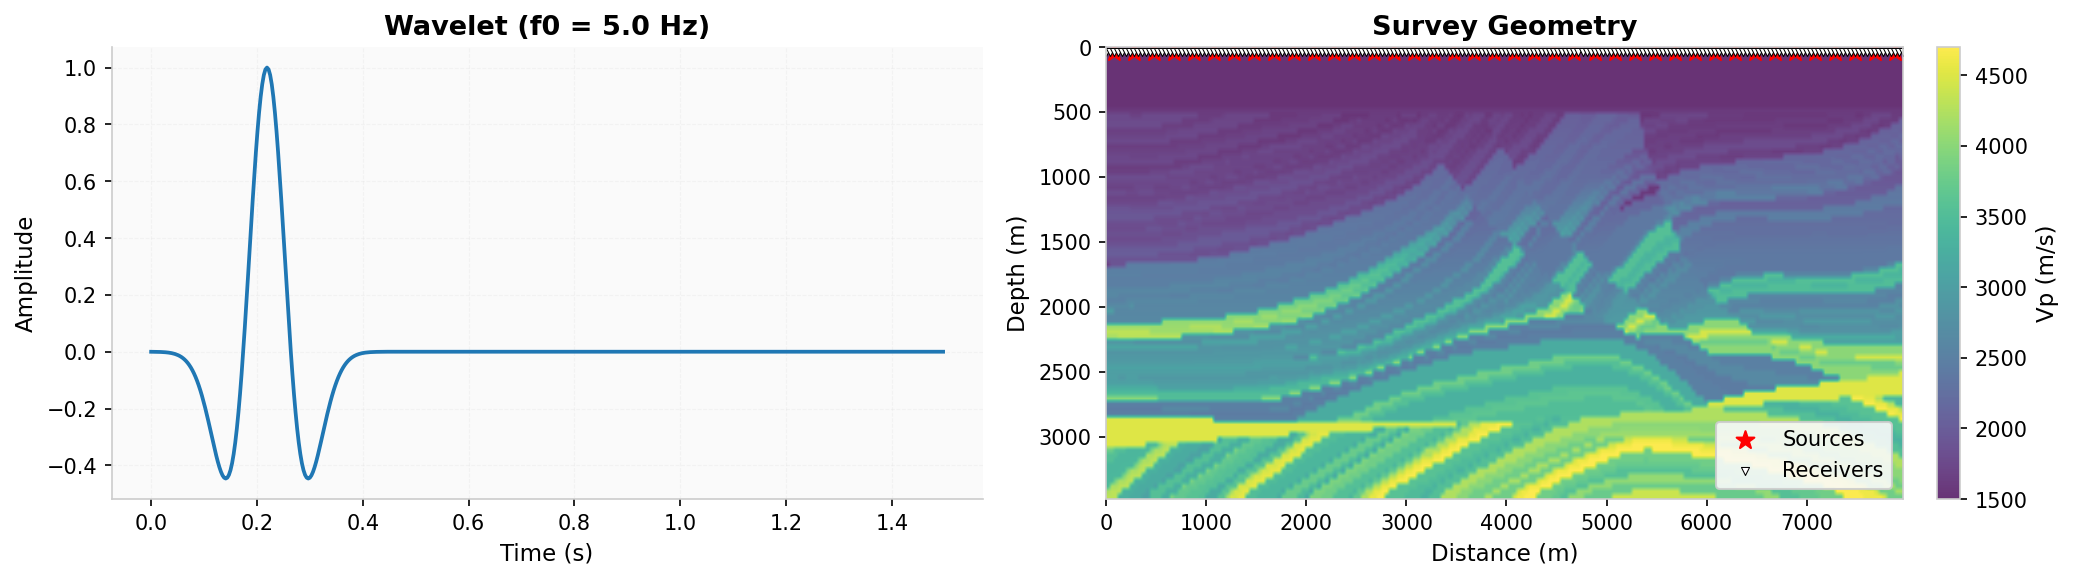

In [6]:
print("\n--- Setup Survey Geometry ---")

# Source positions (every 5 grid points)
src_x = np.array([i for i in range(2, grid.nx - 1, 5)])
src_z = np.array([1 for _ in range(len(src_x))])
n_shots = len(src_x)

# Receiver positions (every grid point)
rcv_x = np.arange(0, grid.nx, 1)
rcv_z = np.ones(len(rcv_x), dtype=int)

print(f"Sources: {n_shots} shots")
print(f"Receivers: {len(rcv_x)} per shot")

# Generate wavelet
ricker = RickerWavelet()
wavelet_tensor, _ = ricker(f0=F0, dt=DT)
wavelet_np = wavelet_tensor.numpy()

# Pad wavelet to match nt
if len(wavelet_np) < NT:
    wavelet_np = np.pad(wavelet_np, (0, NT - len(wavelet_np)), mode='constant')
elif len(wavelet_np) > NT:
    wavelet_np = wavelet_np[:NT]

# Integrate wavelet (velocity source)
from scipy.integrate import cumulative_trapezoid
src_wavelet = cumulative_trapezoid(wavelet_np, initial=0)

# Create Source
source = Source(nt=NT, dt=DT, f0=F0)

for i in range(len(src_x)):
    source.add_source(
        x=int(src_x[i]),
        z=int(src_z[i]),
        wavelet=src_wavelet,
        source_type='mt',
        moment_tensor=np.eye(3),
    )

# Create Receiver
receiver = Receiver(nt=NT, dt=DT)
receiver.add_receivers(x=rcv_x, z=rcv_z, rcv_type='pr')

# Create Survey
survey = Survey(source=source, receiver=receiver)
print(survey)

# Visualize survey geometry
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Wavelet
t_wav = np.arange(500) * DT
axes[0].plot(t_wav, wavelet_np[:500], color='#1f77b4', linewidth=1.8, label='Ricker')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'Wavelet (f0 = {F0} Hz)')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Geometry overlay on velocity model
plot_field(vp, dx=DX, dz=DZ, ax=axes[1], cmap='viridis',
          label='Vp (m/s)', alpha=0.8)
axes[1].scatter(src_x * DX, src_z * DZ, c='red', marker='*', s=80, label='Sources')
axes[1].scatter(rcv_x * DX, rcv_z * DZ, c='white', marker='v', s=15,
                edgecolors='black', linewidth=0.5, label='Receivers')
axes[1].set_title('Survey Geometry')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '07_survey_geometry.png'))
plt.show()

## Forward Simulation

`AcousticPropagator.forward()` marches the acoustic wave equation forward in
time.

- `checkpoint_segments = 4` splits time steps into 4 blocks for gradient
  checkpointing, trading compute for memory so that backpropagation remains
  feasible on large models.

In [7]:
print("\n--- Forward Simulation ---")

propagator = AcousticPropagator(
    model=model,
    survey=survey,
    device=device,
    dtype=dtype,
)

print(f"Running forward simulation for {n_shots} shots...")

result = propagator.forward(checkpoint_segments=4)

rcv_p = result['p']
forward_wavefield = result['forward_wavefield_p']

print(f"Simulation complete!")
print(f"Pressure data shape: {rcv_p.shape}")
print(f"Wavefield shape: {forward_wavefield.shape}")


--- Forward Simulation ---
Running forward simulation for 40 shots...
Simulation complete!
Pressure data shape: torch.Size([40, 3000, 200])
Wavefield shape: torch.Size([88, 200])


## Visualization - Shot Gathers (skill-based)


--- Visualization: Shot Gathers ---


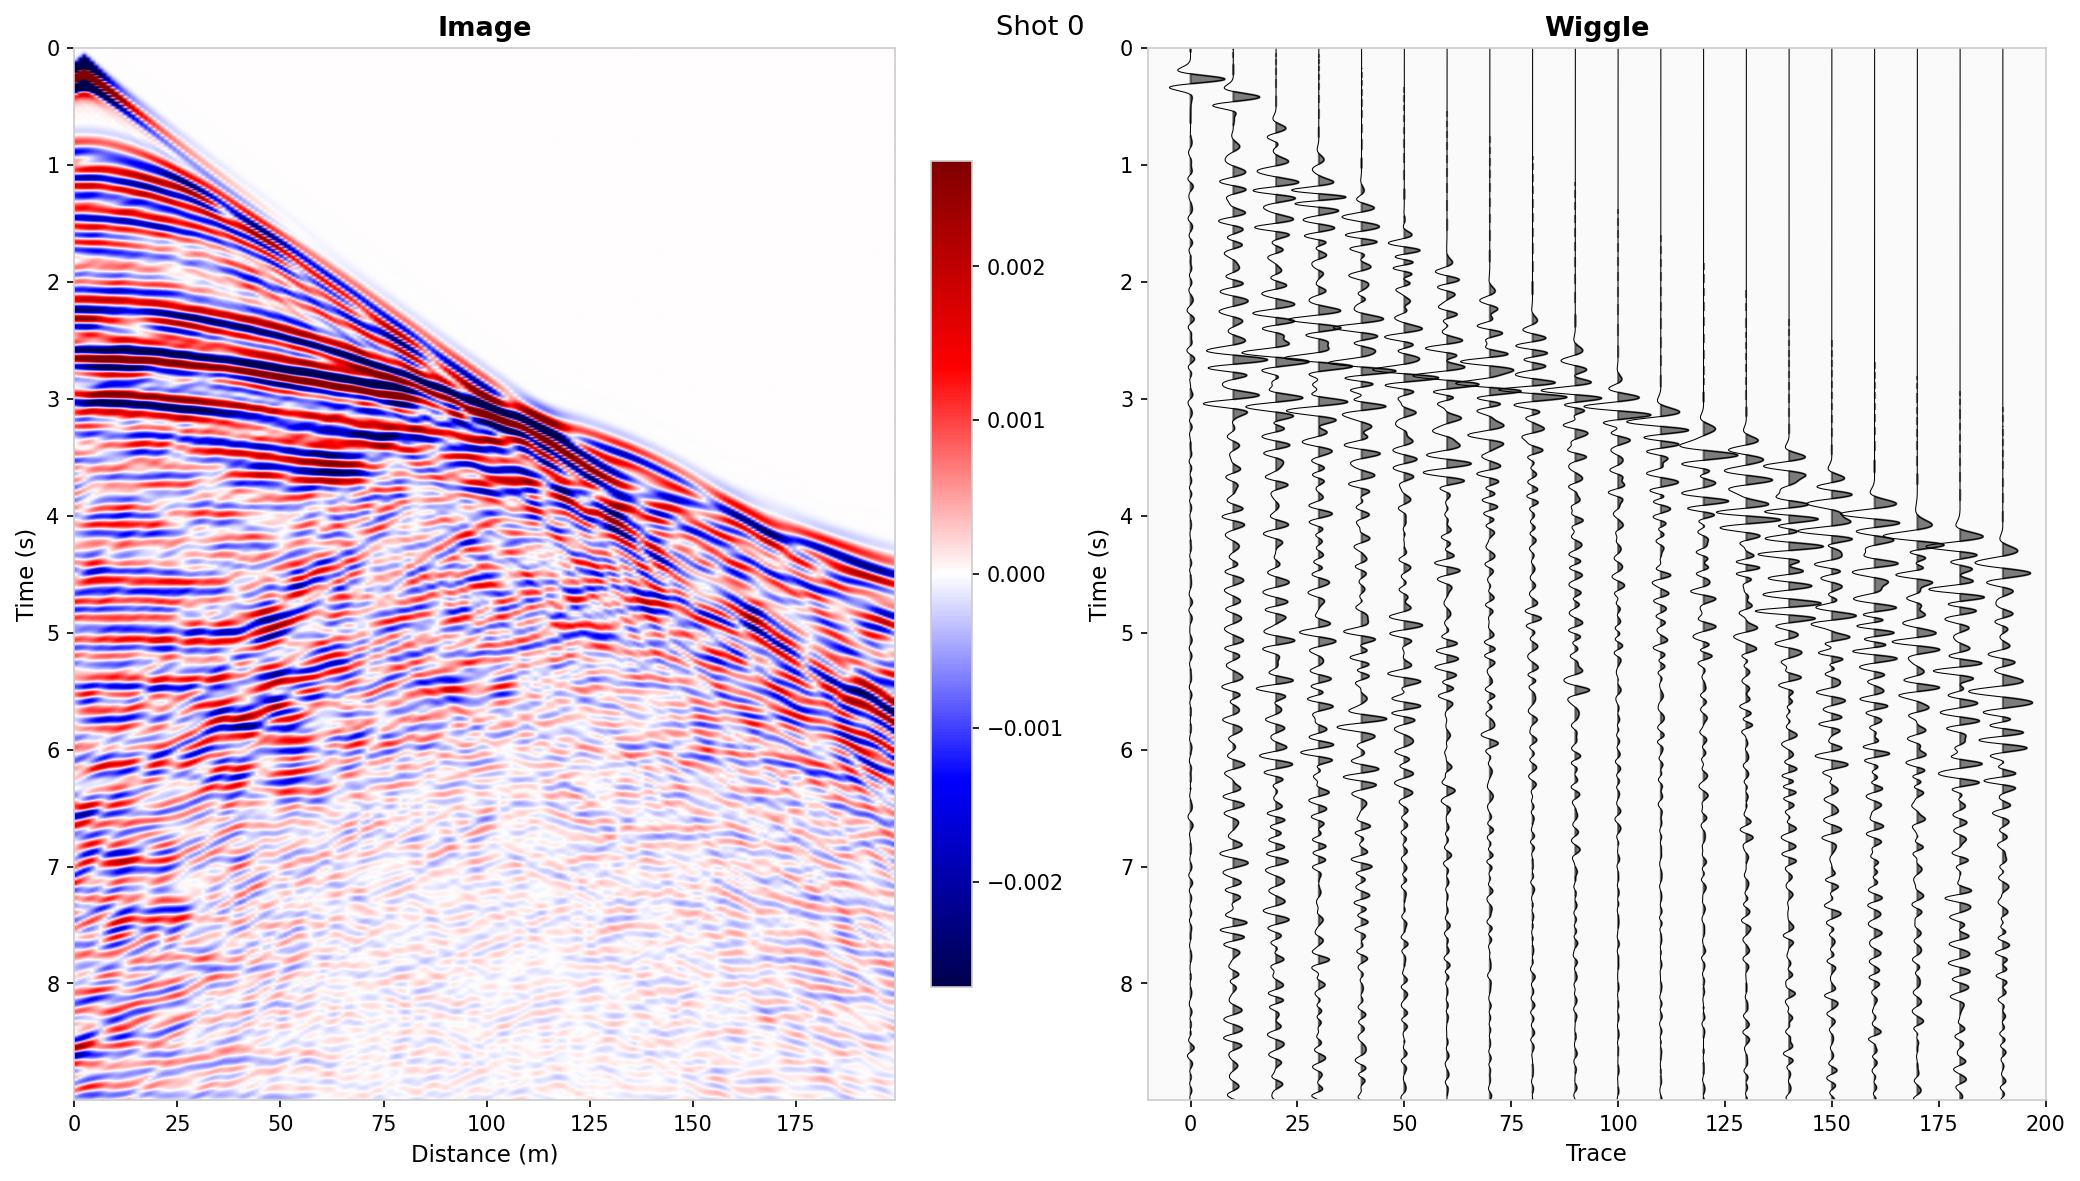

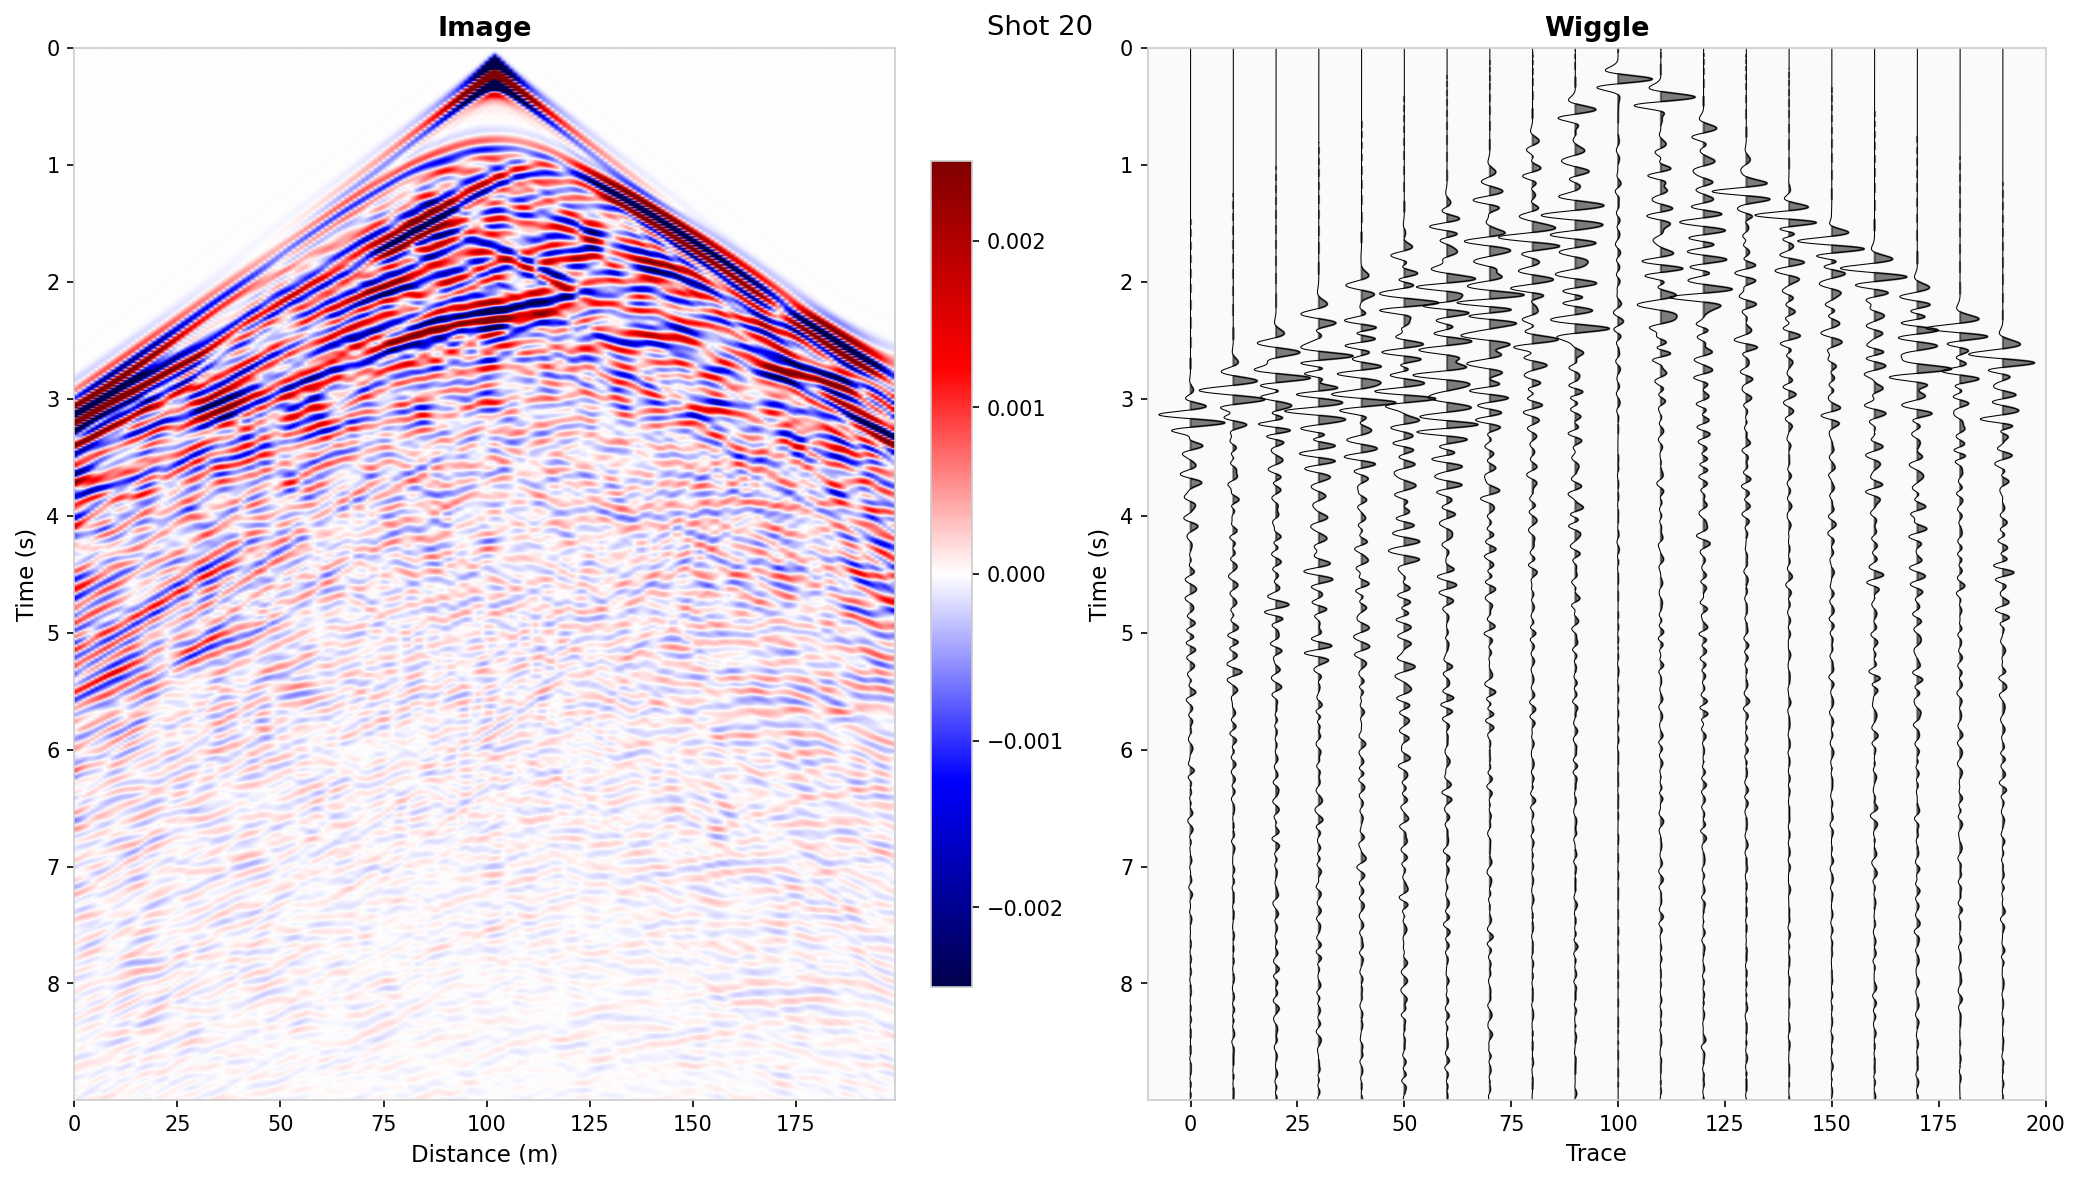

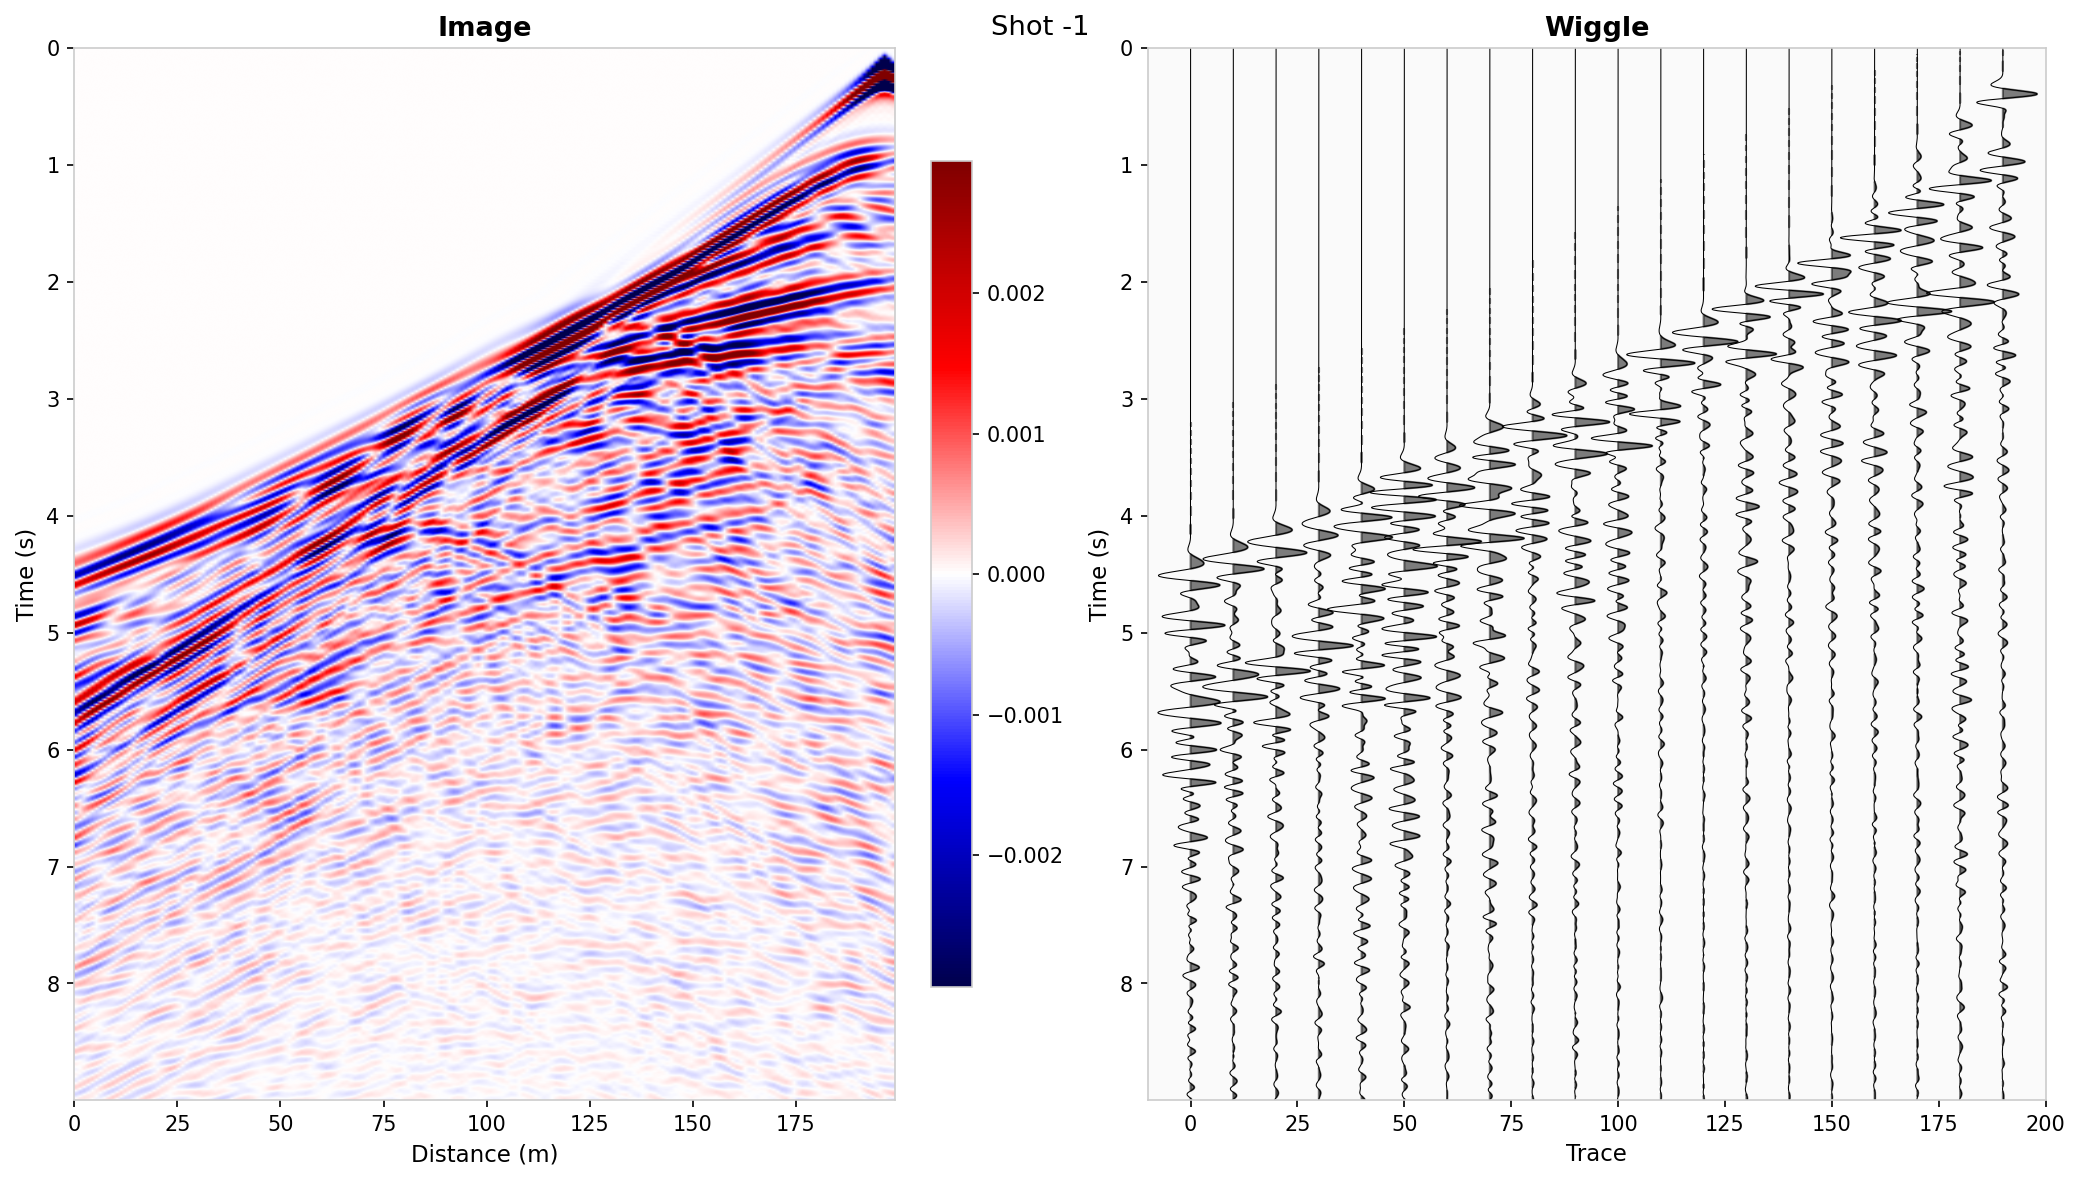

In [8]:
print("\n--- Visualization: Shot Gathers ---")

rcv_p_np = rcv_p.cpu().numpy() if torch.is_tensor(rcv_p) else rcv_p

# Plot selected shots using plot_gather
for i_shot in [0, 20, -1]:
    shot_data = rcv_p_np[i_shot]
    plot_gather(shot_data, dt=DT, dx=1.0, trace_step=10)
    plt.suptitle(f'Shot {i_shot}')
    plt.savefig(os.path.join(FIGS_DIR, f'07_shot_gather_{i_shot}.png'))
    plt.show()

## Wavefield Animation

A single-shot simulation is run with wavefield snapshot output.  The
animation shows acoustic waves propagating through the Marmousi2 velocity
model, revealing reflections, refractions, and diffractions at structural
boundaries.


--- Wavefield Snapshot Animation ---
Running single-shot simulation with snapshots (every 10 steps)...
Captured 300 snapshots, shape: (300, 88, 200)
Time range: 0.030s - 9.000s
Animation saved to acoustic_wavefield.gif


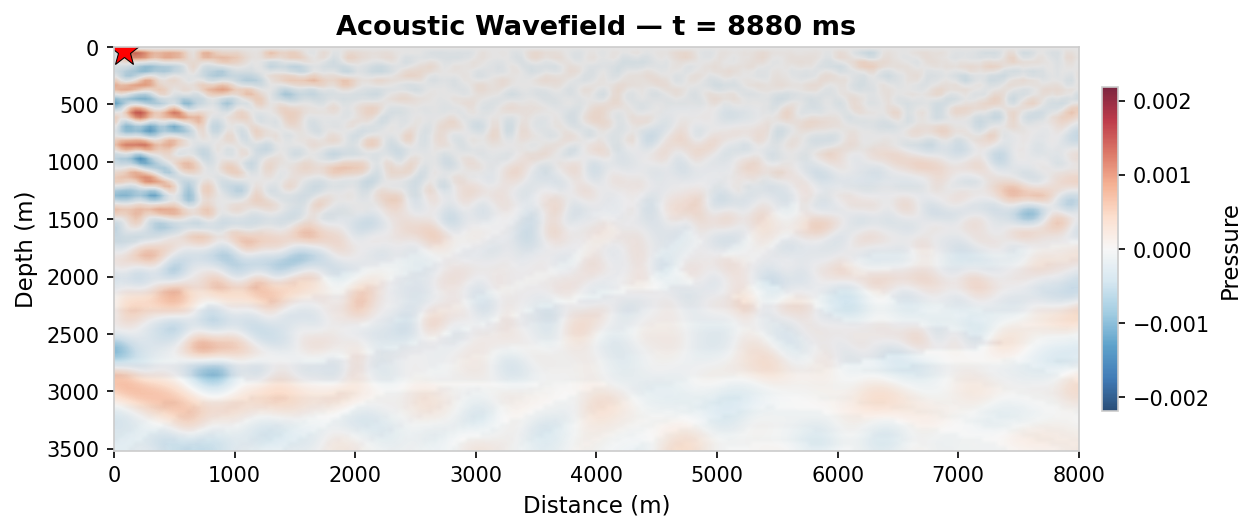

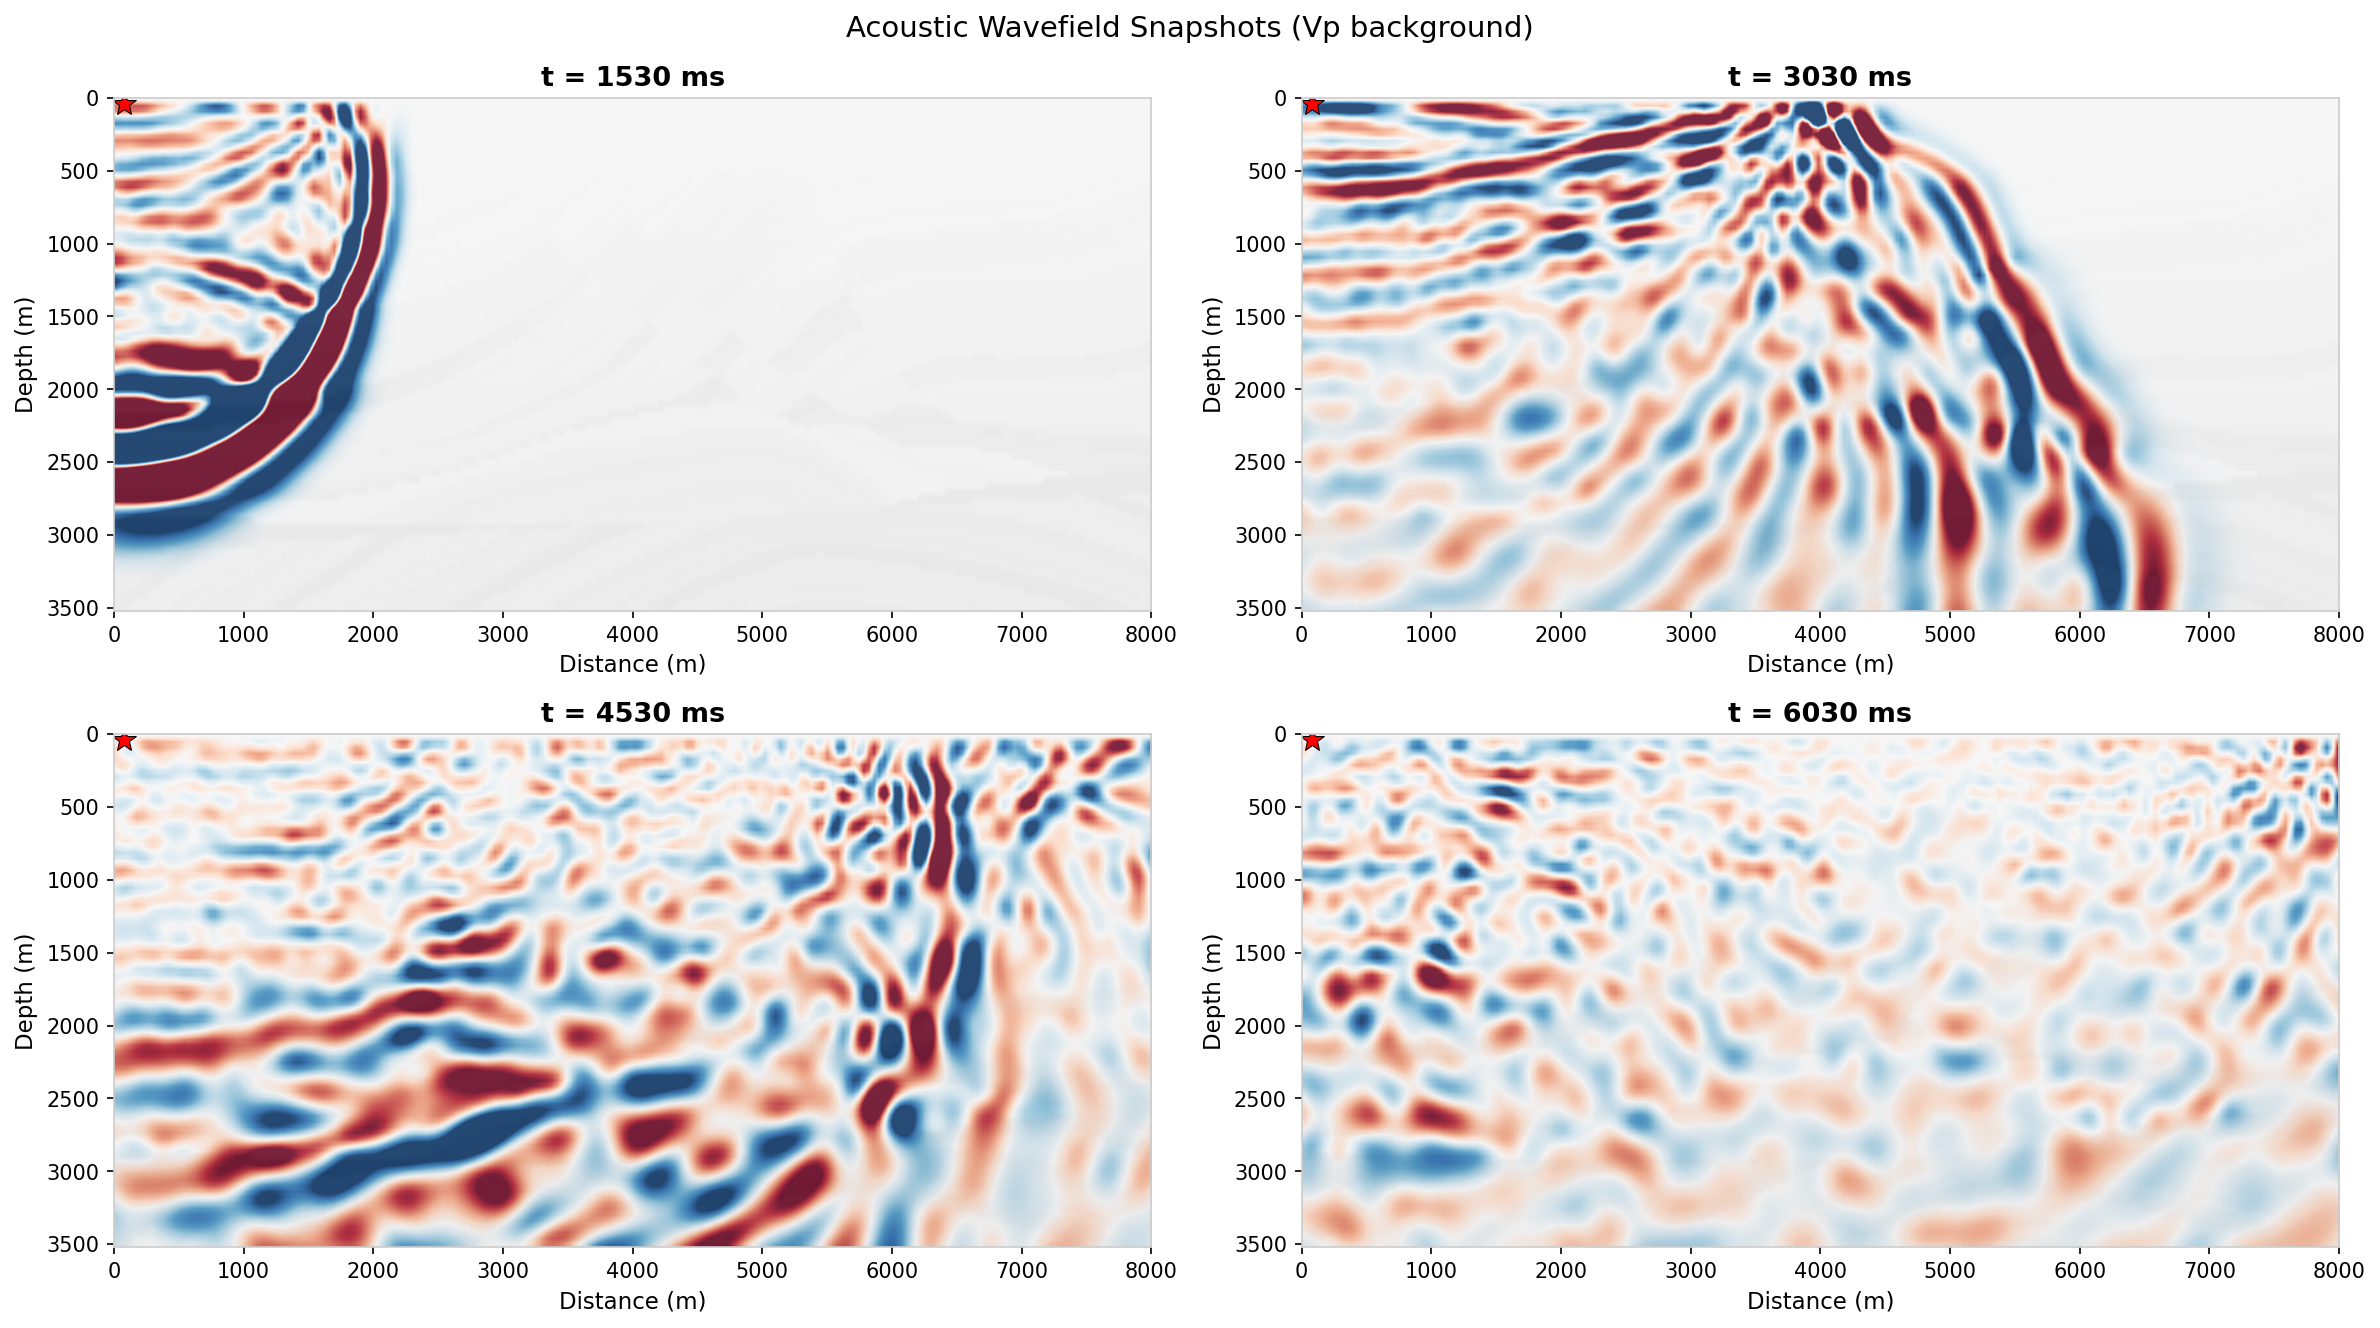

In [9]:
print("\n--- Wavefield Snapshot Animation ---")

from matplotlib.animation import FuncAnimation, PillowWriter

# Run single-shot simulation with snapshots
SNAP_EVERY = 10  # Snapshot every 10 time steps
i_shot_anim = 0

print(f"Running single-shot simulation with snapshots (every {SNAP_EVERY} steps)...")

with torch.no_grad():
    result_snap = propagator.forward(
        shot_index=i_shot_anim,
        snapshot_every=SNAP_EVERY,
    )

snap_data = result_snap.snapshots.numpy()  # (n_snaps, nz, nx)
n_snaps = snap_data.shape[0]
snap_times = np.arange(1, n_snaps + 1) * SNAP_EVERY * DT

print(f"Captured {n_snaps} snapshots, shape: {snap_data.shape}")
print(f"Time range: {snap_times[0]:.3f}s - {snap_times[-1]:.3f}s")

# Determine wavefield clip value (from non-zero snapshots)
nonzero_snaps = snap_data[snap_data.shape[0] // 5:]  # Skip early quiet frames
clip_val = np.percentile(np.abs(nonzero_snaps), 99.5) * 0.6
if clip_val == 0:
    clip_val = np.abs(snap_data).max() * 0.5
if clip_val == 0:
    clip_val = 1.0

extent = [0, NX * DX, NZ * DZ, 0]

# Create figure (smaller size for GIF)
fig, ax = plt.subplots(figsize=(10, 3.5))

# Vp background (geological structure)
im_vp = ax.imshow(vp, extent=extent, aspect='auto', cmap='bone',
                   alpha=0.5, interpolation='bilinear')

# Wavefield overlay
im_wf = ax.imshow(snap_data[0], extent=extent, aspect='auto',
                   cmap='RdBu_r', vmin=-clip_val, vmax=clip_val,
                   alpha=0.85, interpolation='bilinear')

# Source marker
ax.plot(src_x[i_shot_anim] * DX, src_z[i_shot_anim] * DZ,
        'r*', markersize=15, markeredgecolor='k', markeredgewidth=0.5)

ax.set_xlabel('Distance (m)')
ax.set_ylabel('Depth (m)')
title = ax.set_title(f'Acoustic Wavefield — t = {snap_times[0]*1000:.0f} ms')
plt.colorbar(im_wf, ax=ax, label='Pressure', shrink=0.8, pad=0.02)

# Subsample frames to reduce GIF size
frame_step = max(1, n_snaps // 60)
frame_indices = list(range(0, n_snaps, frame_step))

def update(frame):
    im_wf.set_data(snap_data[frame])
    title.set_text(f'Acoustic Wavefield — t = {snap_times[frame]*1000:.0f} ms')
    return [im_wf, title]

anim = FuncAnimation(fig, update, frames=frame_indices, interval=80, blit=True)

# Save as GIF
gif_path = "acoustic_wavefield.gif"
anim.save(gif_path, writer=PillowWriter(fps=15), dpi=80)
print(f"Animation saved to {gif_path}")
plt.show()

# Also save a few key snapshots as static images
key_frames = [n_snaps // 6, n_snaps // 3, n_snaps // 2, 2 * n_snaps // 3]
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

for ax, idx in zip(axes.flat, key_frames):
    ax.imshow(vp, extent=extent, aspect='auto', cmap='gray_r',
              alpha=0.35, interpolation='bilinear')
    ax.imshow(snap_data[idx], extent=extent, aspect='auto',
              cmap='RdBu_r', vmin=-clip_val, vmax=clip_val,
              alpha=0.85, interpolation='bilinear')
    ax.plot(src_x[i_shot_anim] * DX, src_z[i_shot_anim] * DZ,
            'r*', markersize=12, markeredgecolor='k', markeredgewidth=0.5)
    ax.set_title(f't = {snap_times[idx]*1000:.0f} ms')
    ax.set_xlabel('Distance (m)')
    ax.set_ylabel('Depth (m)')

plt.suptitle('Acoustic Wavefield Snapshots (Vp background)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '07_wavefield_snapshots.png'))
plt.show()